In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import joblib

#veri analizi

df = pd.read_csv('dataset.csv')

print(f"Toplam Veri Sayısı: {df.shape[0]}")
print(f"Eksik (NaN) Veri Sayısı:\n{df.isna().sum()}\n")

print("Sınıf Dağılımı:")
print(df['label'].value_counts())

Toplam Veri Sayısı: 6170
Eksik (NaN) Veri Sayısı:
timestamp    0
seq          0
lat          0
lon          0
alt          0
delta        0
label        0
dtype: int64

Sınıf Dağılımı:
label
0    3374
2    2333
3     305
1     158
Name: count, dtype: int64


Keşifçi Veri Analizi (EDA) kapsamında, siber tatbikat sonucunda toplanan ağ telemetri verileri (dataset.csv) sisteme yüklenerek veri setinin genel yapısı incelenmiştir. Eksik veya hatalı değer (NaN) kontrolü gerçekleştirilmiş ve model eğitimine yön verebilmesi amacıyla her bir saldırı sınıfının (Normal, Spoofing, Drift, Jitter) dağılım oranları tespit edilerek raporlanmıştır.

In [2]:
#on isleme ve zaman serisi donusumu

#gereksiz sutunlarin atilmasi
features = df.drop(columns=['timestamp', 'seq', 'label']).values
labels = df['label'].values

#scaling
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

#scaler objesinin kaydedilmesi
joblib.dump(scaler, 'scaler.pkl')

#sliding window (kayan pencere) fonksiyonu
def create_sequences(data, target, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:(i + time_steps)])
        y.append(target[i + time_steps - 1])
    return np.array(X), np.array(y)

TIME_STEPS = 10
X, y = create_sequences(features_scaled, labels, TIME_STEPS)

#etiket kodlama
y_encoded = to_categorical(y, num_classes=4)

Veri ön işleme aşamasında, modelin ezber yapmasını (data leakage) önlemek amacıyla zaman damgası ve sekans numarası sütunları veri setinden çıkarılmıştır. Geriye kalan ağ öznitelikleri, MinMaxScaler kullanılarak 0 ile 1 aralığında ölçeklendirilmiş ve elde edilen ölçekleyici nesne, canlı tespit sisteminde kullanılmak üzere dışa aktarılmıştır. Derin öğrenme modelinin zaman serisi analizi yapabilmesi için veriler, 10'ar paketlik kayan pencere (sliding window) yöntemiyle üç boyutlu tensör formatına dönüştürülmüş ve çok sınıflı sınıflandırma için hedef değişkenlere One-Hot Encoding işlemi uygulanmıştır.

In [3]:
#train validation test ayrimi

#%70 egitim ve %30 gecici ayrimi
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)

#%30'luk kismin %15 validation ve %15 test olarak bolunmesi
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Eğitim Seti (Train) Boyutu    : {X_train.shape}")
print(f"Doğrulama Seti (Val) Boyutu   : {X_val.shape}")
print(f"Test Seti (Test) Boyutu       : {X_test.shape}")

Eğitim Seti (Train) Boyutu    : (4312, 10, 4)
Doğrulama Seti (Val) Boyutu   : (924, 10, 4)
Test Seti (Test) Boyutu       : (924, 10, 4)


Geliştirilen NIDS (Ağ Saldırı Tespit Sistemi) modelinin genellenebilirliğini ve performansını nesnel bir şekilde ölçebilmek amacıyla, hazırlanan zaman serisi verileri üçlü ayrım işlemine tabi tutulmuştur. Sınıf dengesizliklerinin eğitim performansına olumsuz yansımasını engellemek için tabakalı (stratified) bölme yöntemi kullanılmış; veriler sırasıyla %70 eğitim (train), %15 doğrulama (validation) ve %15 test seti olacak şekilde sınıfsal oranları korunarak paylaştırılmıştır.

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam

#1D-CNN + GRU mimarisinin kurulmasi

print("--- Model Mimarisinin İnşası ---")

#modelin girdi boyutu (zaman adimi, ozellik sayisi (10,4))
input_shape = (TIME_STEPS, X_train.shape[2])
num_classes = 4 #NORMAL, SPOOF, DRIFT, JITTER

model = Sequential()

#ozellik cikarimi: 1D-CNN katmanlari
#spoofing anlar
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=input_shape, padding='same'))
model.add(BatchNormalization()) #egitim hizi ve kararliligi icin
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2)) #overfitting engellemek icin

model.add(Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

#zaman serisi: GRU katmanlari
#drift ve jitter anlar
# return_sequences=True: ilk gru'nun ciktisini tam dizi halinde ikinci gru'ya iletir
model.add(GRU(128, return_sequences=True, activation='tanh'))
model.add(Dropout(0.3))

#son gru katmani, tum dizinin ozetini cikarir
model.add(GRU(64, activation='tanh'))
model.add(Dropout(0.3))

#siniflandirma: cikti katmani
#4 sinif icin softmax aktivasyonu
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

#modeli derleme
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

#modelin ozetini ekrana yazdirma
model.summary()

print("[+] 1D-CNN + GRU Modeli başarıyla derlendi.")

--- ADIM 2d: Model Mimarisinin İnşası ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 2, 128)         │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,836 (643.89 KB)

 Trainable params: 164,452 (642.39 KB)

 Non-trainable params: 384 (1.50 KB)

[+] 1D-CNN + GRU Modeli başarıyla derlendi.


Tasarlanan NIDS mimarisi, ağ trafiğindeki farklı saldırı profillerini tespit edebilmek amacıyla 1D-CNN ve GRU katmanlarının entegre edildiği hibrit bir derin öğrenme modeli olarak inşa edilmiştir. Modelin ilk katmanlarında kullanılan 1D Evrişim (Conv1D) ve Ortak Havuzlama (MaxPooling1D) işlemleri, verideki kısa süreli ve keskin anomalileri (örneğin Spoofing saldırıları) uzamsal olarak filtrelemekle görevlendirilmiştir. CNN katmanlarından elde edilen özellik haritaları, daha sonra Geçitli Tekrarlayan Birim (GRU) katmanlarına aktarılarak zaman serisi analizi gerçekleştirilmiştir. GRU birimleri, mikro-sapma (Drift) ve düzensiz ağ gecikmeleri (Jitter) gibi uzun süreli hafıza gerektiren örüntüleri anlamlandırmak için kullanılmıştır. Aşırı öğrenmeyi (overfitting) engellemek maksadıyla mimariye Dropout ve Batch Normalization katmanları dahil edilmiş olup, nihai sınıflandırma işlemi için Softmax aktivasyon fonksiyonuna sahip tam bağlantılı (Dense) çıktı katmanı kullanılarak model derlenmiştir.

In [5]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

#training

print("--- Model Eğitimi Başlıyor ---")

#sinif agirliklarinin hesaplanmasi

y_train_labels = np.argmax(y_train, axis=1)

#agirlik katsayilarinin hesaplanmasi
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weights = dict(enumerate(class_weights_array))

print("Hesaplanan Sınıf Ağırlıkları:")
for cls, weight in class_weights.items():
    print(f"Sınıf {cls}: {weight:.4f}")
print("-" * 40)

#callback

#erken durdurma
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

#en iyi modeli diske kaydetme
model_checkpoint = ModelCheckpoint(
    'best_nids_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

#modelin egitilmesi
EPOCHS = 100
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("-" * 40)
print("[+] Model eğitimi başarıyla tamamlandı ve en iyi ağırlıklar yüklendi.")

--- ADIM 2e: Model Eğitimi Başlıyor ---
Hesaplanan Sınıf Ağırlıkları:
Sınıf 0: 0.4577
Sınıf 1: 9.7117
Sınıf 2: 0.6601
Sınıf 3: 5.0610
----------------------------------------
Epoch 1/100
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7044 - loss: 0.6957
Epoch 1: val_loss improved from None to 1.19863, saving model to best_nids_model.keras

Epoch 1: finished saving model to best_nids_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8462 - loss: 0.4071 - val_accuracy: 0.4210 - val_loss: 1.1986
Epoch 2/100
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9542 - loss: 0.1509
Epoch 2: val_loss improved from 1.19863 to 0.79854, saving model to best_nids_model.keras

Epoch 2: finished saving model to best_nids_model.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9606 - loss: 0.1515 - val_accuracy: 0.6223 - val_loss: 0.7985
Epoch 3/100
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9683 - loss: 0.1242
Epoch 3: val_loss improved from 0

Modelin eğitim aşamasında, ağ trafiğindeki saldırı türlerinin doğal dengesizliğini (class imbalance) gidermek ve azınlık sınıflarının (Spoofing, Jitter) baskılanmasını önlemek amacıyla "sınıf ağırlıklandırma" (class weighting) tekniği uygulanmıştır. Bu sayede modelin nadir görülen anomalilere yönelik duyarlılığı artırılmıştır. Aşırı öğrenmeyi (overfitting) engellemek ve optimum genelleme kapasitesine ulaşmak için "Erken Durdurma" (Early Stopping) ve "Model Kaydetme" (Model Checkpoint) mekanizmaları entegre edilmiştir. Eğitim süreci boyunca doğrulama setindeki (validation set) kayıp fonksiyonu (val_loss) izlenmiş; performansın iyileşmeyi durdurduğu noktada eğitim otomatik olarak sonlandırılarak en yüksek doğruluk oranına sahip ağ ağırlıkları (.keras formatında) sisteme kaydedilmiştir.

--- ADIM 2f: Performans Değerlendirme ---


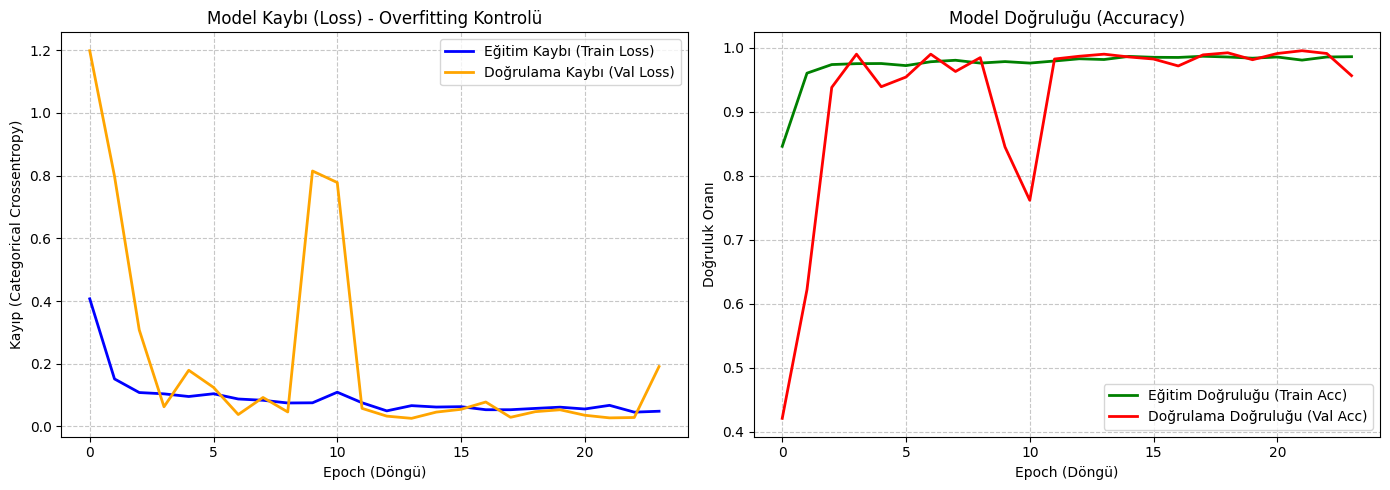


[+] Test seti üzerinde tahminlemeler yapılıyor...
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step

[+] Sınıflandırma Raporu (Classification Report):
              precision    recall  f1-score   support

  NORMAL (0)       0.99      0.99      0.99       504
   SPOOF (1)       0.92      1.00      0.96        24
   DRIFT (2)       1.00      0.98      0.99       350
  JITTER (3)       0.98      1.00      0.99        46

    accuracy                           0.99       924
   macro avg       0.97      0.99      0.98       924
weighted avg       0.99      0.99      0.99       924



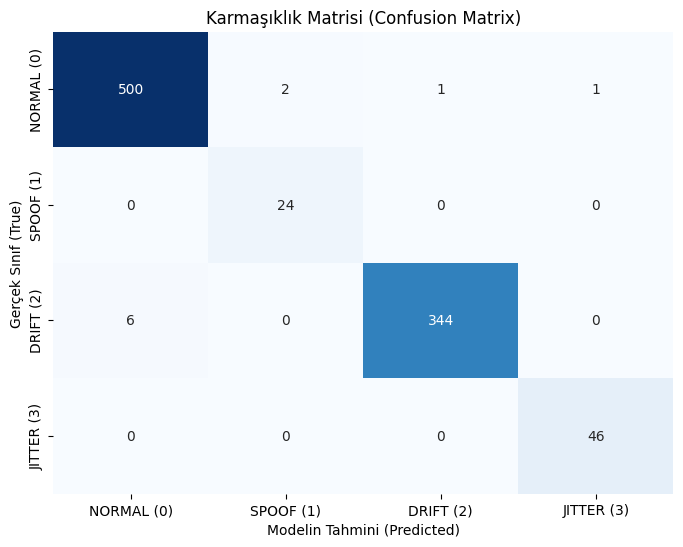


[+] Eğitim tamamlandı. Model 'model.h5' olarak canlı sistem için kaydedildi.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

#performans degerlendirme ve gorsellestirme

print("---Performans Değerlendirme ---")

#egitim ve dogrulama egrileri (overfitting kontrolu)

plt.figure(figsize=(14, 5))

#loss grafigi
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='orange', linewidth=2)
plt.title('Model Kaybı (Loss) - Overfitting Kontrolü')
plt.xlabel('Epoch (Döngü)')
plt.ylabel('Kayıp (Categorical Crossentropy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#accuracy grafigi
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu (Train Acc)', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu (Val Acc)', color='red', linewidth=2)
plt.title('Model Doğruluğu (Accuracy)')
plt.xlabel('Epoch (Döngü)')
plt.ylabel('Doğruluk Oranı')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#test seti uzerinde tahmin islemi
print("\n[+] Test seti üzerinde tahminlemeler yapılıyor...")
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

#etiket isimleri
target_names = ['NORMAL (0)', 'SPOOF (1)', 'DRIFT (2)', 'JITTER (3)']

#siniflandirma raporu
print("\n[+] Sınıflandırma Raporu (Classification Report):")
print(classification_report(y_true, y_pred, target_names=target_names))

#confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, cbar=False)
plt.title('Karmaşıklık Matrisi (Confusion Matrix)')
plt.xlabel('Modelin Tahmini (Predicted)')
plt.ylabel('Gerçek Sınıf (True)')
plt.show()


#modelin disa aktarilmasi
model.save('model.h5')
print("\n[+] Eğitim tamamlandı. Model 'model.h5' olarak canlı sistem için kaydedildi.")

Eğitimi tamamlanan derin öğrenme modelinin performansı ve genellenebilirliği, modelin eğitim sürecinde hiç karşılaşmadığı test seti (test set) üzerinde değerlendirilmiştir. Modelin ezberleme (overfitting) eğiliminde olup olmadığını yapısal olarak kanıtlamak amacıyla, eğitim (train) ve doğrulama (validation) aşamalarına ait kayıp (loss) ve doğruluk (accuracy) değişim eğrileri dönemsel (epoch) olarak çizilmiş ve analiz edilmiştir. Sınıf dengesizliklerinin genel doğruluk (accuracy) metriği üzerindeki yanıltıcı etkisini ortadan kaldırmak için, modelin gerçek tespit performansını yansıtan Kesinlik (Precision), Duyarlılık (Recall) ve F-1 Skoru (F1-Score) metrikleri her bir saldırı sınıfı için ayrı ayrı hesaplanarak raporlanmıştır. Elde edilen tahmin sonuçları, modelin hatalı sınıflandırma eğilimlerini (örneğin Drift saldırısını Normal trafik ile karıştırma ihtimali) detaylı biçimde inceleyebilmek adına Karmaşıklık Matrisi (Confusion Matrix) yöntemiyle ısı haritası formunda görselleştirilmiştir. Geliştirilen nihai model, ağ üzerinde gerçek zamanlı tespitte kullanılmak üzere paketlenerek kaydedilmiştir.